CROP RECOMMENDATION *PROJECT*

In [ ]:
# Import requries libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the data set
data = pd.read_csv("Crop_recommendation.csv")

In [ ]:
print(data.head())
print(data.info())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [ ]:
# check Null values
print(data.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
# Check Duplicates
print(data.duplicated().sum())

0


In [ ]:
# Class distribution
print(data['label'].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [ ]:
# Statistics
print(data.describe())

                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  


In [ ]:
df = data.copy()

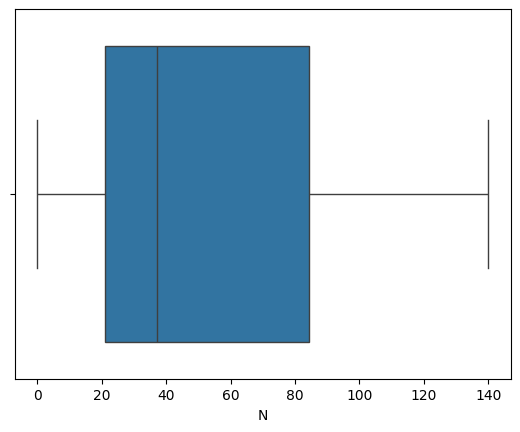

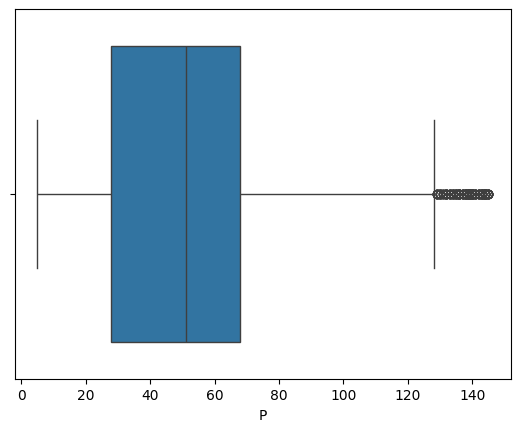

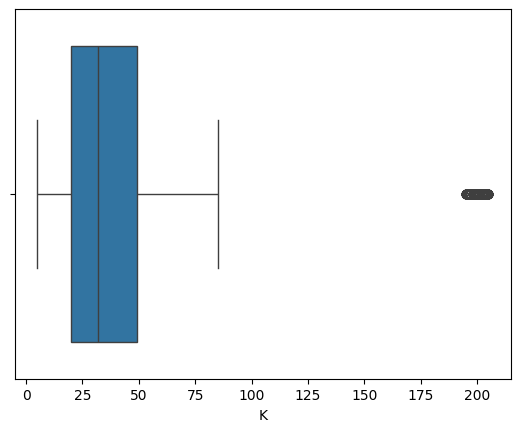

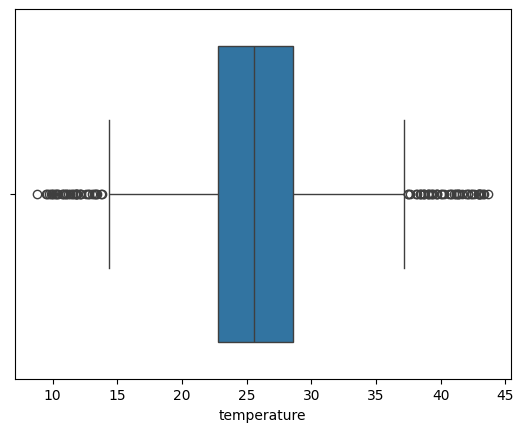

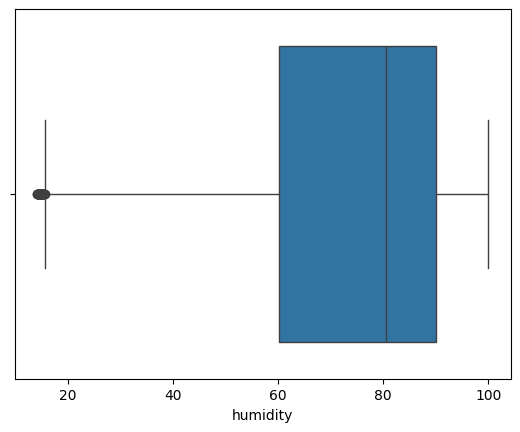

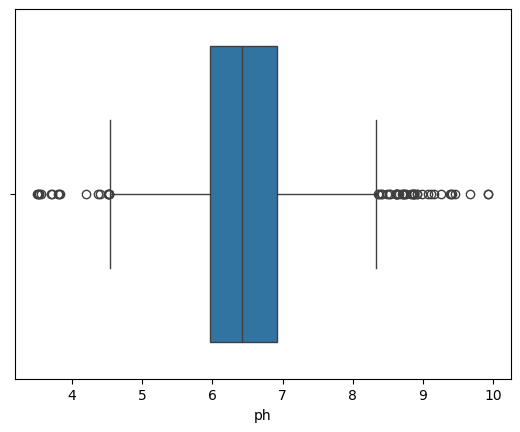

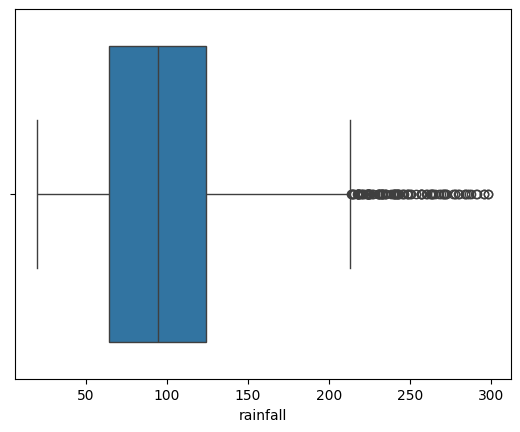

In [ ]:
# Outliers
from scipy import stats

# Boxplots before cleaning
for col in df.columns:
    if df[col].dtype != 'object':
        sns.boxplot(x=df[col])
        plt.show()

In [ ]:
# Split data
X = cleaned_df[['N','P','K','temperature','humidity','ph','rainfall']]
y = cleaned_df['label']

In [ ]:
# Spliting the data in to test and train data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Apply Feature scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# model training
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    oob_score=True
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42)

In [ ]:
print("OOB Score:", model.oob_score_)

OOB Score: 0.9956869993838571


In [ ]:
print("Train Accuracy:", model.score(X_train, y_train))

Train Accuracy: 1.0


In [ ]:
print("Test Accuracy:", model.score(X_test, y_test))

Test Accuracy: 0.9926108374384236


In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [ ]:
import joblib

joblib.dump(model, "crop_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved")

Saved


In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import joblib
import numpy as np

# Load model & scaler
model = joblib.load("crop_model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)[0]

    return f"🌾 Recommended Crop: {prediction}"

# UI Design
with gr.Blocks() as demo:

    gr.Markdown("# 🌱 Smart Crop Recommendation System")
    gr.Markdown("### Enter soil and environmental details")

    with gr.Row():
        N = gr.Number(label="Nitrogen (N)", value=90)
        P = gr.Number(label="Phosphorus (P)", value=42)
        K = gr.Number(label="Potassium (K)", value=43)

    with gr.Row():
        temperature = gr.Number(label="Temperature (°C)", value=25)
        humidity = gr.Number(label="Humidity (%)", value=80)
        ph = gr.Number(label="pH", value=6.5)
        rainfall = gr.Number(label="Rainfall (mm)", value=200)

    btn = gr.Button("🚀 Predict")

    output = gr.Textbox(label="Result")

    btn.click(
        fn=predict_crop,
        inputs=[N, P, K, temperature, humidity, ph, rainfall],
        outputs=output
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://edc8d70932083e2562.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
